## Chapter 2 Exercises from Del Prado Textbook

In [44]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import plotly.graph_objects as go
import plotly.io as pio


from sklearn.preprocessing import MinMaxScaler
from scipy.stats import jarque_bera

To get data, I found this online: https://www.kaggle.com/datasets/finnhub/sp-500-futures-tick-data-sp

In [2]:
# import kagglehub

# path = kagglehub.dataset_download("finnhub/sp-500-futures-tick-data-sp")

# print("Path to dataset files:", path)

In [3]:
path = "/home/tunabeluga/.cache/kagglehub/datasets/finnhub/sp-500-futures-tick-data-sp/versions/1/SP.csv"

data = pd.read_csv(path)
data = data[data["volume"] > 0].copy()

data["datetime"] = pd.to_datetime(
    data["date"].astype(str) + "/" + data["time"].astype(str),
    format="%m/%d/%Y/%H:%M:%S.%f"
)

data = data.sort_values("datetime")
data = data.set_index("datetime")

print(type(data.index))
print(data.index.min(), data.index.max())
print(data.head())

# Choosing a subset (2010 year for example)
data_subset = data.loc["2010-01-01":"2010-12-31"].copy()

<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
2003-06-30 23:00:06 2019-12-31 02:21:45.011000
                           date          time  price  volume
datetime                                                    
2003-06-30 23:00:06  06/30/2003  23:00:06.000  971.9       1
2003-06-30 23:00:14  06/30/2003  23:00:14.000  972.0       1
2003-06-30 23:04:16  06/30/2003  23:04:16.000  972.0       1
2003-06-30 23:04:34  06/30/2003  23:04:34.000  972.0       9
2003-06-30 23:05:02  06/30/2003  23:05:02.000  972.0      91


### 2.4

In [5]:
def make_dollar_bars(df, dollar_threshold, price_col="price", volume_col="volume", multiplier=50):
    bars = []

    cum_dollar = 0
    cum_volume = 0
    prices = []
    start_time = None

    for time, row in df.iterrows():
        price = row[price_col]
        volume = row[volume_col]

        if start_time is None:
            start_time = time

        dollar_value = price * volume * multiplier
        cum_dollar += dollar_value
        cum_volume += volume
        prices.append(price)

        if cum_dollar >= dollar_threshold:
            bars.append({"datetime": time, "start_time": start_time, "open": prices[0], "high": max(prices), "low": min(prices), "close": prices[-1], "volume": cum_volume, "dollar_value": cum_dollar, "num_ticks": len(prices)})
            cum_dollar = 0
            cum_volume = 0
            prices = []
            start_time = None

    bars = pd.DataFrame(bars)
    bars = bars.set_index("datetime")

    return bars

In [6]:
multiplier = 50

data_subset["dollar_value"] = data_subset["price"] * data_subset["volume"] * multiplier

daily_dollar_volume = data_subset["dollar_value"].resample("1D").sum()
daily_dollar_volume = daily_dollar_volume[daily_dollar_volume > 0]

target_bars_per_day = 50
dollar_threshold = daily_dollar_volume.mean() / target_bars_per_day

print("Dollar threshold:", dollar_threshold)
print("Subset rows:", len(data_subset))

dollar_bars = make_dollar_bars(
    data_subset,
    dollar_threshold=dollar_threshold,
    price_col="price",
    volume_col="volume",
    multiplier=multiplier
)

dollar_bars["ret"] = dollar_bars["close"].pct_change()
dollar_bars = dollar_bars.dropna()

print(dollar_bars.head())
print("Number of dollar bars:", len(dollar_bars))

Dollar threshold: 3193940.872903226
Subset rows: 661511
                             start_time    open    high     low   close  \
datetime                                                                  
2010-01-03 17:06:31 2010-01-03 17:01:21  1114.3  1115.0  1114.2  1114.9   
2010-01-03 17:48:28 2010-01-03 17:06:31  1114.9  1116.1  1114.8  1115.3   
2010-01-03 19:05:39 2010-01-03 17:48:28  1115.3  1116.1  1115.1  1115.7   
2010-01-03 20:04:34 2010-01-03 19:05:43  1115.7  1116.0  1114.5  1114.5   
2010-01-03 22:04:18 2010-01-03 20:04:34  1114.5  1115.6  1114.5  1115.2   

                     volume  dollar_value  num_ticks       ret  
datetime                                                        
2010-01-03 17:06:31      59     3288170.0         32  0.000538  
2010-01-03 17:48:28      59     3290920.0         42  0.000359  
2010-01-03 19:05:39      58     3235450.0         54  0.000359  
2010-01-03 20:04:34      58     3234265.0         27 -0.001076  
2010-01-03 22:04:18      58 

Total number of intersections: 0


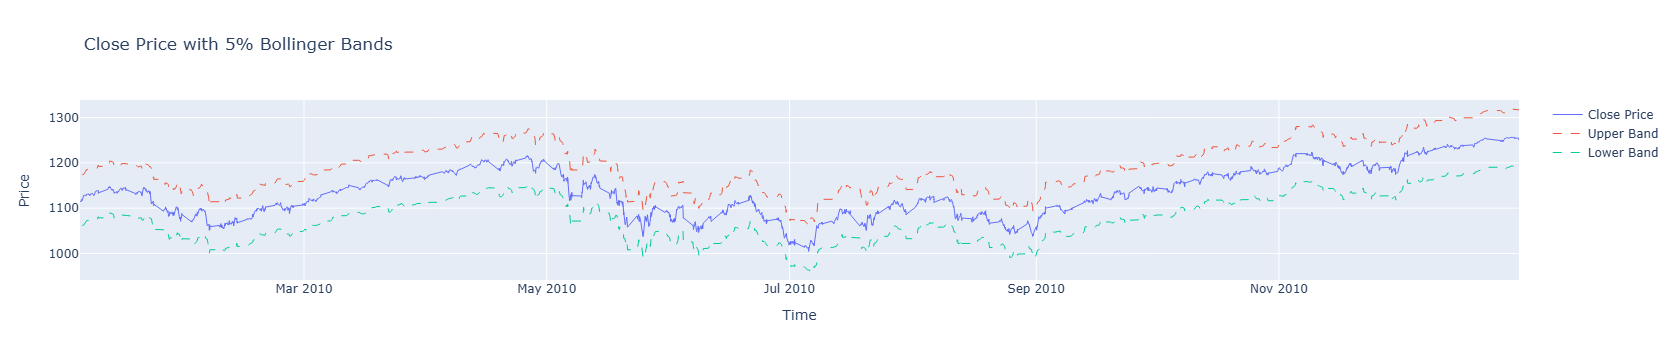

'\nAs the plot shows, in 2010, no Bollinger band crossings\n'

In [45]:
# (a)

df = dollar_bars.copy()
df = df.sort_index()

window = 24

df["rolling_mean"] = df["close"].rolling(window).mean()
df["b_upper"] = df["rolling_mean"] * 1.05
df["b_lower"] = df["rolling_mean"] * 0.95

def get_num_intersect(df):
    num_intersect = 0

    for _, row in df.dropna(subset=["b_upper", "b_lower"]).iterrows():
        open_price = row["open"]
        close_price = row["close"]
        upper = row["b_upper"]
        lower = row["b_lower"]

        crosses_upper = open_price < upper and close_price > upper
        crosses_lower = open_price > lower and close_price < lower

        if crosses_upper or crosses_lower:
            num_intersect += 1

    return num_intersect

print("Total number of intersections:", get_num_intersect(df))


fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index, y=df["close"], line=dict(width=1),name="Close Price"))
fig.add_trace(go.Scatter(x=df.index, y=df["b_upper"], line=dict(width=1, dash="dash"), name="Upper Band"))
fig.add_trace(go.Scatter(x=df.index, y=df["b_lower"], line=dict(width=1, dash="dash"), name="Lower Band"))
fig.update_layout(title="Close Price with 5% Bollinger Bands", xaxis_title="Time", yaxis_title="Price")
fig.show()

'''
As the plot shows, in 2010, no Bollinger band crossings
'''

Number of selected timestamps: 22


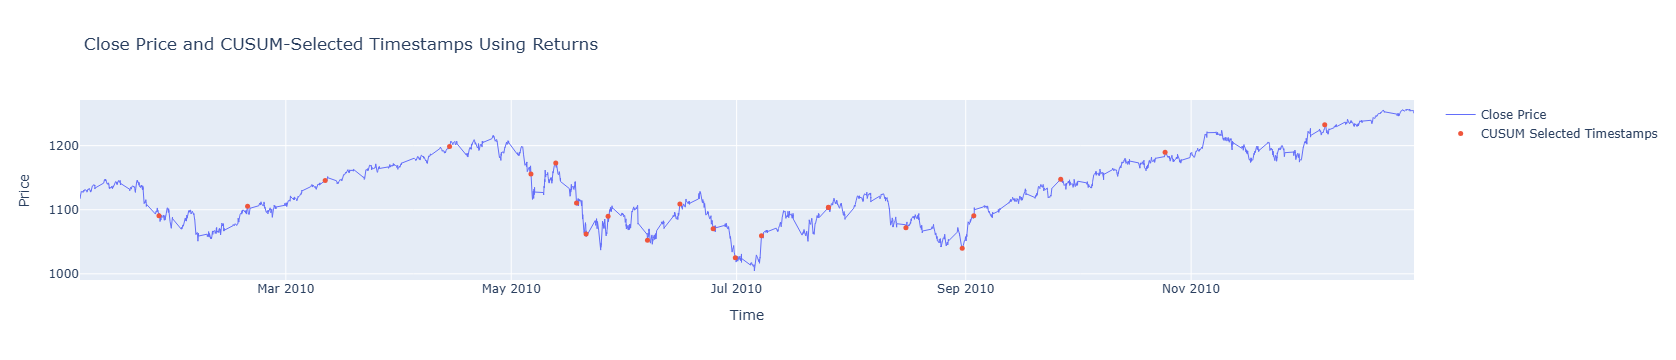

In [51]:
# (b)
def getTEvents(gRaw, h): # From Del Prado
    tEvents = []
    sPos, sNeg = 0, 0

    diff = gRaw.diff().dropna()

    for t, x in diff.items():
        sPos = max(0, sPos + x)
        sNeg = min(0, sNeg + x)

        if sNeg < -h:
            sNeg = 0
            tEvents.append(t)
        elif sPos > h:
            sPos = 0
            tEvents.append(t)

    return pd.DatetimeIndex(tEvents)

df["ret"] = df["close"].pct_change()
df = df.dropna()

h = 0.05   # use 0.05 if it gives enough events

events_24 = getTEvents(df["ret"].cumsum(), h=h)
chosen_bars_24 = df.loc[events_24]

print("Number of selected timestamps:", len(chosen_bars_24))

fig = go.Figure()
fig.add_trace(go.Scatter(x=df.index,y=df["close"],line=dict(width=1),name="Close Price"))
fig.add_trace(go.Scatter(x=chosen_bars_24.index,y=chosen_bars_24["close"],mode="markers",marker=dict(size=5),name="CUSUM Selected Timestamps"))
fig.update_layout( title="Close Price and CUSUM-Selected Timestamps Using Returns",xaxis_title="Time",yaxis_title="Price")
fig.show()

In [52]:
# (c)

window = 20

# Rolling std of returns for the two sampled series
sampled_24["rolling_std"] = sampled_24["ret"].rolling(window).std()
sampled_25["rolling_std"] = sampled_25["ret"].rolling(window).std()

# Variance of rolling std = simple heteroscedasticity measure
std_var_24 = sampled_24["rolling_std"].dropna().var()
std_var_25 = sampled_25["rolling_std"].dropna().var()

print("CUSUM on returns:")
print("Number of samples:", len(sampled_24))
print("Variance of rolling std:", std_var_24)

print("\nCUSUM on absolute returns:")
print("Number of samples:", len(sampled_25))
print("Variance of rolling std:", std_var_25)

if std_var_24 < std_var_25:
    print("\nLeast heteroscedastic: CUSUM on returns")
else:
    print("\nLeast heteroscedastic: CUSUM on absolute returns")

# CUSUM on returns had the smallest variance of rolling standard deviation, indicating that its volatility was more stable over time.

CUSUM on returns:
Number of samples: 22
Variance of rolling std: 8.4291754842355e-09

CUSUM on absolute returns:
Number of samples: 1856
Variance of rolling std: 2.2307155058656815e-06

Least heteroscedastic: CUSUM on returns


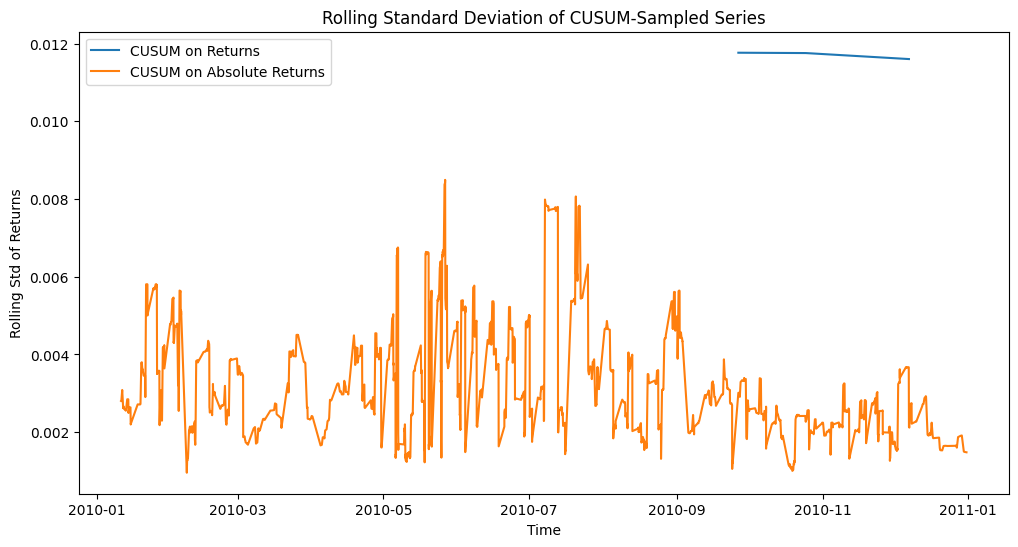

'\nThis does not look right\n'

In [53]:
plt.figure(figsize=(12, 6))

plt.plot(sampled_24.index, sampled_24["rolling_std"], label="CUSUM on Returns")
plt.plot(sampled_25.index, sampled_25["rolling_std"], label="CUSUM on Absolute Returns")
plt.title("Rolling Standard Deviation of CUSUM-Sampled Series")
plt.xlabel("Time")
plt.ylabel("Rolling Std of Returns")
plt.legend()
plt.show()

'''
This does not look right
'''

## 2.5


In [54]:
h = 0.05

# Absolute returns
df["abs_ret"] = df["ret"].abs()
cum_abs_ret = df["abs_ret"].cumsum()

events_25 = getTEvents(cum_abs_ret, h=h)
sampled_25 = df.loc[events_25].copy()

print("Number of CUSUM samples using absolute returns:", len(sampled_25))
print(sampled_25.head())

Number of CUSUM samples using absolute returns: 218
                             start_time    open    high     low   close  \
2010-01-06 21:00:00 2010-01-06 18:46:46  1133.5  1133.5  1131.5  1132.1   
2010-01-10 17:49:46 2010-01-10 17:41:46  1144.4  1146.1  1143.1  1145.9   
2010-01-12 20:40:06 2010-01-12 19:16:41  1134.6  1136.8  1134.0  1136.6   
2010-01-15 02:05:42 2010-01-15 01:15:13  1143.5  1144.3  1142.0  1142.5   
2010-01-18 17:01:39 2010-01-18 17:00:00  1136.5  1137.1  1136.5  1137.1   

                     volume  dollar_value  num_ticks       ret  rolling_mean  \
2010-01-06 21:00:00      57     3228405.0         46 -0.001235   1129.829167   
2010-01-10 17:49:46      57     3262780.0         31  0.001311   1136.720833   
2010-01-12 20:40:06      57     3234260.0         46  0.001763   1134.541667   
2010-01-15 02:05:42      56     3201560.0         48 -0.000875   1141.795833   
2010-01-18 17:01:39      61     3466830.0         18  0.000528   1135.362500   

                

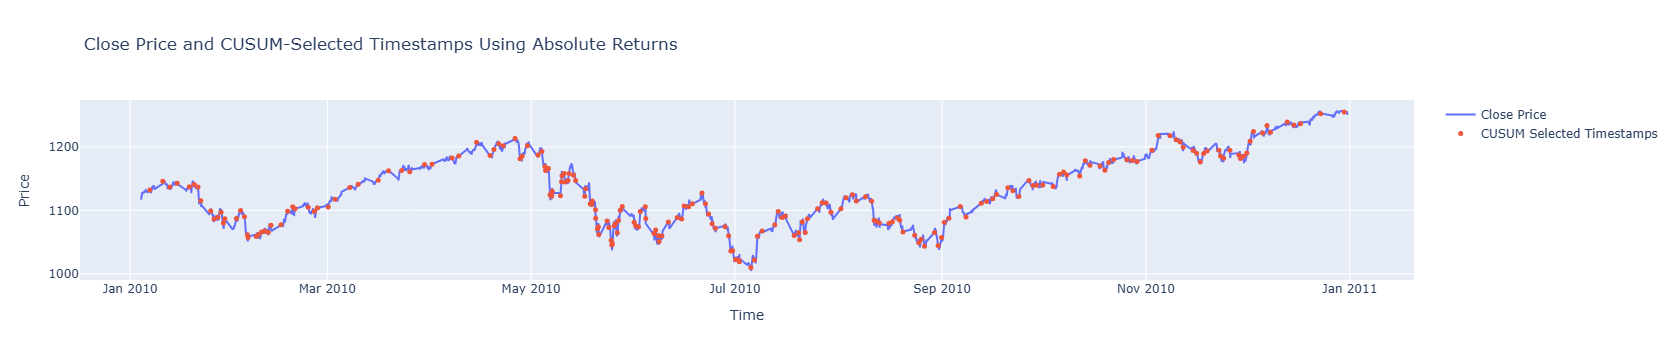

In [55]:
# (a)
fig = go.Figure()

fig.add_trace(go.Scatter(x=df.index,y=df["close"],mode="lines",name="Close Price"))
fig.add_trace(go.Scatter(x=sampled_25.index,y=sampled_25["close"],mode="markers",marker=dict(size=5),name="CUSUM Selected Timestamps"))
fig.update_layout( title="Close Price and CUSUM-Selected Timestamps Using Absolute Returns",xaxis_title="Time", yaxis_title="Price")
fig.show()

Number of sampled observations: 218
Variance of rolling std, CUSUM absolute returns: 6.808179253975576e-06


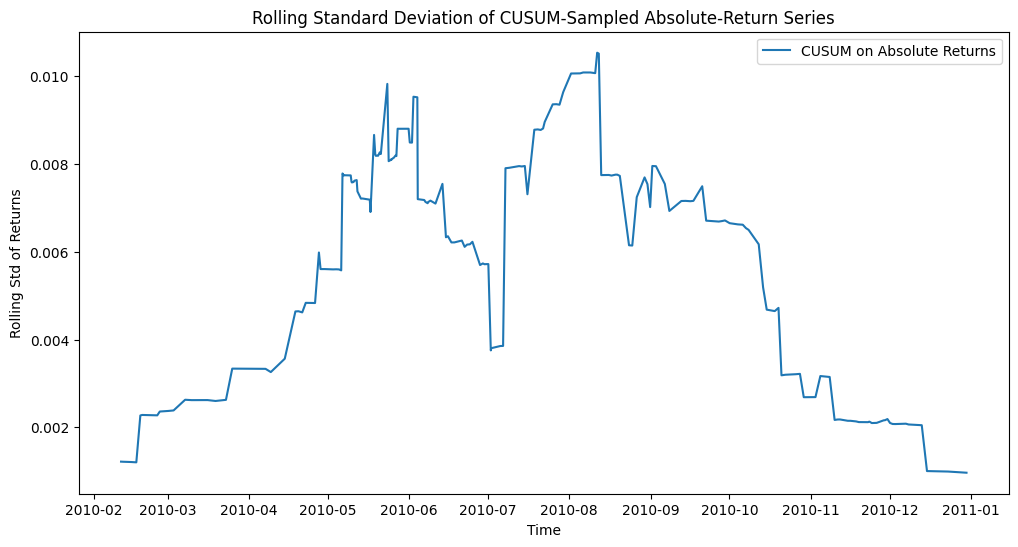

In [58]:
# (b)
window = 24

sampled_25["rolling_std"] = sampled_25["ret"].rolling(window).std()

std_var_sampled_25 = sampled_25["rolling_std"].dropna().var()

print("Number of sampled observations:", len(sampled_25))
print("Variance of rolling std, CUSUM absolute returns:", std_var_sampled_25)

plt.figure(figsize=(12, 6))
plt.plot(sampled_25.index, sampled_25["rolling_std"], label="CUSUM on Absolute Returns")
plt.title("Rolling Standard Deviation of CUSUM-Sampled Absolute-Return Series")
plt.xlabel("Time")
plt.ylabel("Rolling Std of Returns")
plt.legend()
plt.show()

Variance of rolling std, CUSUM on returns: 8.4291754842355e-09
Variance of rolling std, CUSUM on absolute returns: 7.724052063519556e-06
Least heteroscedastic: CUSUM on returns


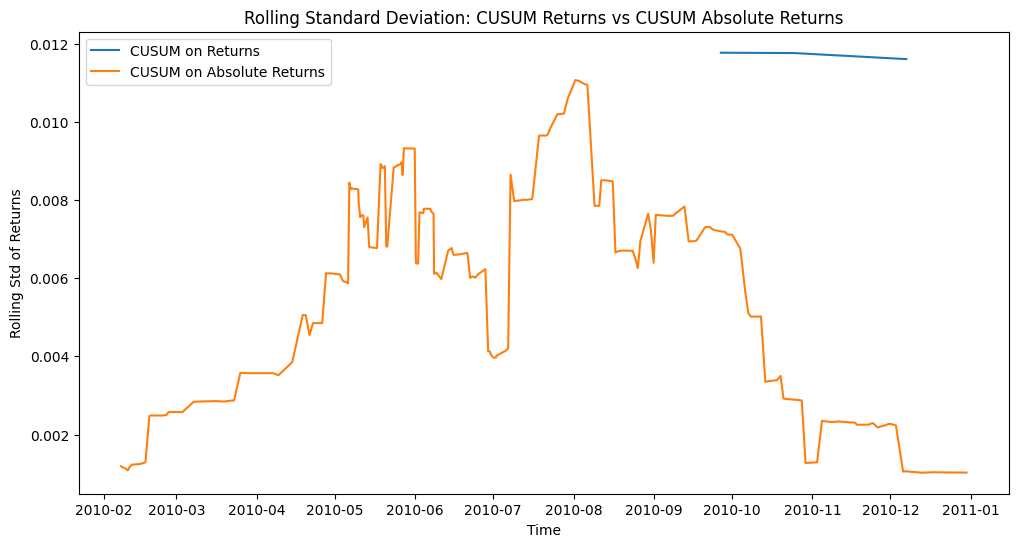

'\nYea something is wrong with the CUSUM on Returns\n'

In [62]:
# (c)
window = 20

sampled_24["rolling_std"] = sampled_24["ret"].rolling(window).std()
sampled_25["rolling_std"] = sampled_25["ret"].rolling(window).std()

std_var_24 = sampled_24["rolling_std"].dropna().var()
std_var_25 = sampled_25["rolling_std"].dropna().var()

print("Variance of rolling std, CUSUM on returns:", std_var_24)
print("Variance of rolling std, CUSUM on absolute returns:", std_var_25)

if std_var_24 < std_var_25:
    print("Least heteroscedastic: CUSUM on returns")
else:
    print("Least heteroscedastic: CUSUM on absolute returns")

plt.figure(figsize=(12, 6))
plt.plot(sampled_24.index, sampled_24["rolling_std"], label="CUSUM on Returns")
plt.plot(sampled_25.index, sampled_25["rolling_std"], label="CUSUM on Absolute Returns")
plt.title("Rolling Standard Deviation: CUSUM Returns vs CUSUM Absolute Returns")
plt.xlabel("Time")
plt.ylabel("Rolling Std of Returns")
plt.legend()
plt.show()

'''
Yea something is wrong with the CUSUM on Returns
'''